In [2]:
import numpy as np
import pandas as pd
from rdkit import Chem
#
import deepchem.feat.molecule_featurizers.mol_graph_conv_featurizer as mgcf
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
#
import torch
import torch.nn as nn
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
from torch.utils.data import DataLoader, Dataset, Subset
from torch_geometric.nn import GCNConv, GINConv, GATConv, global_mean_pool, global_add_pool
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torch.backends.cudnn as cudnn

import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading some PyTorch models, missing a dependency. No module named 'transformers'
No module named 'transformers'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'transformers'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped 

Using device: cuda


In [3]:
# Hyperparameters
BATCH_SIZE = 64
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
EPOCHS = 100
DROPOUT_P = 0.5
EARLY_STOP_PATIENCE = 5
PRINT_EVERY = 5
#SPLIT_STRATEGY = "scaffold"  # options: 'scaffold' or 'random'
RANDOM_SEED = 42
TEST_RATIO = 0.2
VAL_RATIO = 0.2

import random
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)  # for multi-GPU

cudnn.deterministic = True
cudnn.benchmark = False

In [4]:
class GraphDataset(Dataset):
    def __init__(self, graphs, labels=None):
        self.graphs = graphs
        if labels is not None:
            self.labels = torch.tensor(labels, dtype=torch.float32)
        else:
            self.labels = None
    def __len__(self):
        return len(self.graphs)
    def __getitem__(self, idx):
        if self.labels is not None:
            return self.graphs[idx], self.labels[idx]
        else:
            return self.graphs[idx]

In [14]:
#load training and test data
df_train = pd.read_csv("train_data.csv")
df_test = pd.read_csv("test_data.csv")
print(f"Training set size: {len(df_train)}")
print(f"Test set size: {len(df_test)}")

# Graph Featurization (ignore edge features for simplicity)
featurizer = mgcf.MolGraphConvFeaturizer(use_edges=False)

for i in [df_train, df_test]:
    smiles = i["stereo_smiles"].tolist()
    graphs = list(featurizer.featurize(smiles))
    y = i["LUMO_eV"].to_numpy().astype(np.float32)
    dataset = GraphDataset(graphs, y)
    num_features = dataset.graphs[0].node_features.shape[1]
    print(f"Detected input feature dimension (num_features): {num_features}")
    if i is df_train:
        train_dataset = dataset
    else:
        test_dataset = dataset

# Custom collate function for batching graphs
def graph_collate(batch):
    graphs_batch, labels_batch = zip(*batch)
    return list(graphs_batch), torch.stack(labels_batch)

#split training data into training and validation sets
num_train = len(train_dataset)
num_test = len(test_dataset)
num_val = int(num_train * VAL_RATIO)
num_train = num_train - num_val
train_indices = list(range(len(train_dataset)))
random.shuffle(train_indices)   
train_indices, val_indices = train_indices[:num_train], train_indices[num_train:]

train_loader = DataLoader(
    Subset(train_dataset, train_indices), 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=graph_collate
)
val_loader = DataLoader(
    Subset(train_dataset, val_indices), 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=graph_collate
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=graph_collate
)

Training set size: 12798
Test set size: 3203
Detected input feature dimension (num_features): 30
Detected input feature dimension (num_features): 30


In [15]:
# TRAIN/VALIDATION/TEST UTILITIES
def reset_all_seeds(seed=RANDOM_SEED):
    """Reset ALL sources of randomness for perfect reproducibility."""
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_model(model, train_loader, val_loader, epochs, optimizer, criterion, device, print_every=5, scheduler=None, early_stop_patience=None):
    """Train model for regression, with optional LR scheduler and early stopping by Validation Loss."""
    best_val_loss = float('inf')
    best_state = None
    patience_left = early_stop_patience if early_stop_patience is not None else None
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_count = 0
        for graphs_batch, labels_batch in train_loader:
            optimizer.zero_grad()
            labels_batch = labels_batch.to(device)
            # Ensure labels are correct shape for regression
            if labels_batch.dim() == 1:
                labels_batch = labels_batch.unsqueeze(1)
                
            logits = model(graphs_batch)
            loss = criterion(logits, labels_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(labels_batch)
            total_count += len(labels_batch)
            
        avg_train_loss = total_loss / total_count if total_count > 0 else float("nan")
        
        # Evaluate on validation set (MSE)
        _, _, avg_val_loss = evaluate_model(model, val_loader, device, criterion)
        
        # Scheduler step (Monitor Val Loss, usually 'min' mode)
        if scheduler is not None and avg_val_loss is not None:
            scheduler.step(avg_val_loss)
            
        # Early stopping tracking (Minimize Loss)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            if patience_left is not None:
                patience_left = early_stop_patience
        else:
            if patience_left is not None:
                patience_left -= 1
                if patience_left <= 0:
                    print(f"Early stopping at epoch {epoch:02d} | Best Val Loss: {best_val_loss:.4f}")
                    if best_state is not None:
                        model.load_state_dict(best_state)
                    break
                    
        if epoch % print_every == 0:
            print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            
    # Restore best state at end if not already
    if best_state is not None:
        model.load_state_dict(best_state)
    return model

def evaluate_model(model, loader, device, criterion=None):
    """Run model in eval mode over loader and return predictions, labels, and optional avg loss."""
    model.eval()
    preds = []
    labels = []
    total_loss = 0.0
    total_count = 0
    with torch.no_grad():
        for graphs_batch, labels_batch in loader:
            labels_batch = labels_batch.to(device)
            if labels_batch.dim() == 1:
                labels_batch = labels_batch.unsqueeze(1)
                
            logits = model(graphs_batch) # For regression, these are the raw predictions
            
            if criterion is not None:
                total_loss += criterion(logits, labels_batch).item() * len(labels_batch)
                
            preds.extend(logits.cpu().numpy().flatten())
            labels.extend(labels_batch.cpu().numpy().flatten())
            total_count += len(labels_batch)
            
    avg_loss = total_loss / total_count if criterion is not None and total_count > 0 else None
    return preds, labels, avg_loss

def training_and_evaluation(model_class, train_loader, val_loader, test_loader, num_features, hidden_dim=HIDDEN_DIM, seed=RANDOM_SEED, lr=LEARNING_RATE, epochs=EPOCHS, print_every=PRINT_EVERY, early_stop_patience=EARLY_STOP_PATIENCE, device='cuda'):

    reset_all_seeds(seed)
    model = model_class(in_features=num_features, dim_h=hidden_dim).to(device)
    model_type = model.__class__.__name__
    print(f"\nTraining model for REGRESSION: {model_type}")
    
    reset_all_seeds(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    
    # Use MSE Loss for regression
    criterion = nn.MSELoss()
    
    # Scheduler: reduce LR when validation loss stops decreasing ('min' mode)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
    
    # TRAINING
    reset_all_seeds(seed)
    train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
        print_every=print_every,
        scheduler=scheduler,
        early_stop_patience=early_stop_patience,
    )

    # EVALUATION ON TEST SET
    reset_all_seeds(seed)
    model.eval()
    test_preds, test_labels, test_loss = evaluate_model(
        model, test_loader, device, criterion
    )
    
    # Calculate Regression Metrics
    test_r2 = r2_score(test_labels, test_preds)
    test_rmse = np.sqrt(mean_squared_error(test_labels, test_preds))
    test_mae = mean_absolute_error(test_labels, test_preds)
    
    print(f"Test MSE Loss: {test_loss:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test MAE: {test_mae:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    return model, test_r2, test_rmse, test_mae

In [16]:
# GCN MODEL DEFINITION
class GCN(torch.nn.Module):


    """Graph Convolutional Network class with 3 convolutional layers and a linear layer"""

    def __init__(self, in_features, dim_h):
        super().__init__()
        self.conv1 = GCNConv(in_features, dim_h)
        self.conv2 = GCNConv(dim_h, dim_h)
        self.conv3 = GCNConv(dim_h, dim_h)
        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, graphs_in):
        
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)

        x_list = []
        edge_list = []
        batch = []
        node_offset = 0

        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)

            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GCNConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")
            
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)

        # GCN layers
        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = x.relu()
        x = self.conv3(x, e)
        
        # Global Pooling (Graph-level prediction)
        # A visualization of message passing, node embedding, and global pooling 
        # might be helpful here. 
        x = global_mean_pool(x, batch)

        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)

        return x # Return shape [batch_size, 1] for regression   
# GIN MODEL DEFINITION
class GIN(torch.nn.Module):
    """Graph Isomorphism Network class with 3 GINConv layers and 1 linear layer
    
    Note: BatchNorm is essential for GIN stability because:
    - GIN uses sum aggregation (scale-dependent)
    - Deeper MLPs (2 Linear layers) need normalization
    - Prevents gradient instability during training
    
    GIN uses global_add_pool (SUM) rather than global_mean_pool because:
    - Preserves injectivity required for WL-test expressiveness
    - Different graph structures produce different sums (but may have same mean)
    - This is GIN's key theoretical advantage over GCN/GAT
    """

    def __init__(self, in_features, dim_h):
        """Initializing GIN class

        Args:
            in_features (int): number of input features
            dim_h (int): the dimension of hidden layers
        """
        super(GIN, self).__init__()
        # Add BatchNorm for stability - critical for GIN!
        self.conv1 = GINConv(
            Sequential(Linear(in_features, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.conv2 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.conv3 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(), 
                      Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU())
        )
        self.lin = Linear(dim_h, 1)

    def forward(self, graphs_in):
        
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)

        x_list = []
        edge_list = []
        batch = []
        node_offset = 0

        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)

            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GINConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")
            
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)

        # GIN layers with sum aggregation (more powerful but needs BatchNorm)
        x = self.conv1(x, e)
        x = self.conv2(x, e)
        x = self.conv3(x, e)
        
        # Global Pooling: Use SUM for GIN to preserve theoretical properties
        # This maintains injectivity - different graphs → different representations
        x = global_add_pool(x, batch)

        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)
        return x # Return shape [batch_size, 1] for regression 
# GAT MODEL DEFINITION
class GAT(torch.nn.Module):
    """Graph Attention Network class with 3 GATConv layers and 1 linear layer"""

    def __init__(self, in_features, dim_h, heads=3):
        """Initializing GAT class

        Args:
            in_features (int): number of input features
            dim_h (int): the dimension of hidden layers
            heads (int): number of attention heads
        """
        super(GAT, self).__init__()
        self.conv1 = GATConv(in_features, dim_h, heads=heads, concat=True)
        self.conv2 = GATConv(dim_h * heads, dim_h, heads=heads, concat=True)
        self.conv3 = GATConv(dim_h * heads, dim_h, heads=1, concat=False)
        self.lin = Linear(dim_h, 1)

    def forward(self, graphs_in):
        
        # Normalize input to a list of graph objects
        graphs_list = list(graphs_in)

        x_list = []
        edge_list = []
        batch = []
        node_offset = 0

        # Build concatenated Tensors (x, edge_index, batch vector)
        for i, g in enumerate(graphs_list):
            
            # Convert node features (nf) to tensor and move to device
            nf = torch.tensor(g.node_features, dtype=torch.float32).to(device)

            # Convert edge index (ei) to tensor and move to device
            ei = torch.tensor(g.edge_index, dtype=torch.long)
            
            # Correctly Reshape/Transpose edge_index：
            # deepchem's featurizer outputs shape [num_edges, 2]. 
            # PyG's GATConv expects [2, num_edges].
            if ei.dim() == 2 and ei.shape[1] == 2:
                ei = ei.t().contiguous().to(device)
            elif ei.dim() == 2 and ei.shape[0] == 2:
                ei = ei.to(device) # already correct shape
            else:
                raise ValueError("Edge index shape mismatch. Expected [N, 2] or [2, N].")
            
            # Shift edge indices by the current node offset
            edge_list.append(ei + node_offset)
            x_list.append(nf)
            
            n_nodes = nf.shape[0]
            batch.append(torch.full((n_nodes,), i, dtype=torch.long, device=device))
            node_offset += n_nodes
        
        # Concatenate all features, edges, and batch vectors
        x = torch.cat(x_list, dim=0)
        e = torch.cat(edge_list, dim=1)
        batch = torch.cat(batch, dim=0)

        # GAT layers with attention mechanism
        x = self.conv1(x, e)
        x = x.relu()
        x = self.conv2(x, e)
        x = x.relu()
        x = self.conv3(x, e)
        
        # Global Pooling (Graph-level prediction)
        x = global_mean_pool(x, batch)

        # Readout layer
        x = Fun.dropout(x, p=DROPOUT_P, training=self.training)
        x = self.lin(x) # Output logits (unscaled)

        return x # Return shape [batch_size, 1] for regression

In [17]:
BATCH_SIZE = 64
HIDDEN_DIM = 32
LEARNING_RATE = 0.001
RANDOM_SEED = 42

In [ ]:
# Train and evaluate the model using the updated regression function
gcn_model, test_r2, test_rmse, test_mae = training_and_evaluation(
    GCN, 
    train_loader, 
    val_loader, 
    test_loader, 
    num_features, 
    seed=RANDOM_SEED
)

print(f"Final Model Performance:")
print(f"R2 Score: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")


Training model for REGRESSION: GCN
Epoch 05 | Train Loss: 2.0222 | Val Loss: 0.1771
Early stopping at epoch 09 | Best Val Loss: 0.1031
Test MSE Loss: 0.0972
Test RMSE: 0.3117
Test MAE: 0.2286
Test R2: 0.3505
Final Model Performance:
R2 Score: 0.3505
RMSE: 0.3117
MAE: 0.2286


In [19]:
# Train and evaluate the model using the updated regression function
gat_model, test_r2, test_rmse, test_mae = training_and_evaluation(
    GAT, 
    train_loader, 
    val_loader, 
    test_loader, 
    num_features, 
    seed=RANDOM_SEED
)

print(f"Final Model Performance:")
print(f"R2 Score: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")


Training model for REGRESSION: GAT
Epoch 05 | Train Loss: 1.9916 | Val Loss: 0.0794
Epoch 10 | Train Loss: 1.8770 | Val Loss: 0.2622
Early stopping at epoch 13 | Best Val Loss: 0.0785
Test MSE Loss: 0.0722
Test RMSE: 0.2686
Test MAE: 0.2071
Test R2: 0.5176
Final Model Performance:
R2 Score: 0.5176
RMSE: 0.2686
MAE: 0.2071


In [20]:
# Train and evaluate the model using the updated regression function
gin_model, test_r2, test_rmse, test_mae = training_and_evaluation(
    GIN, 
    train_loader, 
    val_loader, 
    test_loader, 
    num_features, 
    seed=RANDOM_SEED
)

print(f"Final Model Performance:")
print(f"R2 Score: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")


Training model for REGRESSION: GIN
Epoch 05 | Train Loss: 3.1109 | Val Loss: 0.7283
Epoch 10 | Train Loss: 2.2661 | Val Loss: 0.4003
Epoch 15 | Train Loss: 1.8489 | Val Loss: 0.3101
Epoch 20 | Train Loss: 1.5768 | Val Loss: 0.2895
Epoch 25 | Train Loss: 1.3395 | Val Loss: 0.1935
Epoch 30 | Train Loss: 1.1030 | Val Loss: 0.1450
Epoch 35 | Train Loss: 0.9093 | Val Loss: 0.1423
Epoch 40 | Train Loss: 0.7037 | Val Loss: 0.1047
Epoch 45 | Train Loss: 0.5825 | Val Loss: 0.1362
Epoch 50 | Train Loss: 0.4603 | Val Loss: 0.0765
Epoch 55 | Train Loss: 0.3435 | Val Loss: 0.1052
Epoch 60 | Train Loss: 0.2686 | Val Loss: 0.0554
Epoch 65 | Train Loss: 0.1920 | Val Loss: 0.0541
Epoch 70 | Train Loss: 0.1464 | Val Loss: 0.0489
Epoch 75 | Train Loss: 0.1080 | Val Loss: 0.0474
Epoch 80 | Train Loss: 0.0806 | Val Loss: 0.0559
Early stopping at epoch 82 | Best Val Loss: 0.0427
Test MSE Loss: 0.0414
Test RMSE: 0.2035
Test MAE: 0.1484
Test R2: 0.7231
Final Model Performance:
R2 Score: 0.7231
RMSE: 0.2035
M

In [22]:
# HYPERPARAMETER SCREENING

import itertools
import math
from datetime import datetime

# Define hyperparameter grid
BATCH_SIZE_GRID = [64, 16, 32, 128, 256]
HIDDEN_DIM_GRID = [32, 16, 8, 64]
LEARNING_RATE_GRID = [0.001, 0.0005, 0.0001]
RANDOM_SEED_GRID = [42, 21, 0]

# Storage for results - now includes seed information
results_per_seed = []

# Total combinations
total_combinations = len(BATCH_SIZE_GRID) * len(HIDDEN_DIM_GRID) * len(LEARNING_RATE_GRID) * len(RANDOM_SEED_GRID)
print(f"Starting hyperparameter screening with {total_combinations} combinations...")
print(f"(Testing {len(BATCH_SIZE_GRID)} batch sizes × {len(HIDDEN_DIM_GRID)} hidden dims × {len(LEARNING_RATE_GRID)} learning rates × {len(RANDOM_SEED_GRID)} seeds)")
print(f"Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 100)

combination_counter = 0

for batch_size, hidden_dim, lr, seed in itertools.product(BATCH_SIZE_GRID, HIDDEN_DIM_GRID, LEARNING_RATE_GRID, RANDOM_SEED_GRID):
    combination_counter += 1
    print(f"\n[{combination_counter}/{total_combinations}] Testing: BATCH_SIZE={batch_size}, HIDDEN_DIM={hidden_dim}, LR={lr}, SEED={seed}")
    
    # Re-create DataLoaders with the current batch_size
    current_train_loader = DataLoader(
        Subset(train_dataset, train_indices), 
        batch_size=batch_size, 
        shuffle=False, 
        collate_fn=graph_collate
    )
    current_val_loader = DataLoader(
        Subset(train_dataset, val_indices), 
        batch_size=batch_size, 
        shuffle=False, 
        collate_fn=graph_collate
    )
    current_test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        collate_fn=graph_collate
    )

    # GCN
    try:
        model_temp, gcn_test_r2, gcn_test_rmse, gcn_test_mae = training_and_evaluation(
            model_class=GCN,
            train_loader=current_train_loader, 
            val_loader=current_val_loader, 
            test_loader=current_test_loader, 
            num_features=num_features,
            hidden_dim=hidden_dim,
            seed=seed,
            lr=lr,
        )
    except Exception as e:
        print(f"GCN Failed: {e}")
        gcn_test_r2, gcn_test_rmse, gcn_test_mae = -999, -999, -999

    # GIN
    try:
        model_temp, gin_test_r2, gin_test_rmse, gin_test_mae = training_and_evaluation(
            model_class=GIN,
            train_loader=current_train_loader, 
            val_loader=current_val_loader, 
            test_loader=current_test_loader, 
            num_features=num_features,
            hidden_dim=hidden_dim,
            seed=seed,
            lr=lr,
        )
    except Exception as e:
        print(f"GIN Failed: {e}")
        gin_test_r2, gin_test_rmse, gin_test_mae = -999, -999, -999

    # GAT
    try:
        model_temp, gat_test_r2, gat_test_rmse, gat_test_mae = training_and_evaluation(
            model_class=GAT,
            train_loader=current_train_loader, 
            val_loader=current_val_loader, 
            test_loader=current_test_loader, 
            num_features=num_features,
            hidden_dim=hidden_dim,
            seed=seed,
            lr=lr,
        )
    except Exception as e:
        print(f"GAT Failed: {e}")
        gat_test_r2, gat_test_rmse, gat_test_mae = -999, -999, -999

    # Store results with seed information
    result = {
        'batch_size': batch_size,
        'hidden_dim': hidden_dim,
        'learning_rate': lr,
        'random_seed': seed,
        # GCN
        'gcn_test_r2': gcn_test_r2,
        'gcn_test_rmse': gcn_test_rmse,
        'gcn_test_mae': gcn_test_mae,
        # GIN
        'gin_test_r2': gin_test_r2,
        'gin_test_rmse': gin_test_rmse,
        'gin_test_mae': gin_test_mae,
        # GAT
        'gat_test_r2': gat_test_r2,
        'gat_test_rmse': gat_test_rmse,
        'gat_test_mae': gat_test_mae,
    }
    results_per_seed.append(result)

print("\n" + "=" * 100)
print(f"Screening completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Total combinations tested: {len(results_per_seed)}")
print(f"Unique hyperparameter combinations: {len(results_per_seed) // len(RANDOM_SEED_GRID)}")

Starting hyperparameter screening with 180 combinations...
(Testing 5 batch sizes × 4 hidden dims × 3 learning rates × 3 seeds)
Started at: 2026-02-27 16:02:15

[1/180] Testing: BATCH_SIZE=64, HIDDEN_DIM=32, LR=0.001, SEED=42

Training model for REGRESSION: GCN
Epoch 05 | Train Loss: 2.0222 | Val Loss: 0.1771
Early stopping at epoch 09 | Best Val Loss: 0.1031
Test MSE Loss: 0.0971
Test RMSE: 0.3117
Test MAE: 0.2285
Test R2: 0.3507

Training model for REGRESSION: GIN
Epoch 05 | Train Loss: 3.1126 | Val Loss: 0.7286
Epoch 10 | Train Loss: 2.2690 | Val Loss: 0.3924
Epoch 15 | Train Loss: 1.8375 | Val Loss: 0.2793
Epoch 20 | Train Loss: 1.5858 | Val Loss: 0.2811
Epoch 25 | Train Loss: 1.3387 | Val Loss: 0.1996
Epoch 30 | Train Loss: 1.1044 | Val Loss: 0.1890
Epoch 35 | Train Loss: 0.9050 | Val Loss: 0.1520
Epoch 40 | Train Loss: 0.6982 | Val Loss: 0.0992
Epoch 45 | Train Loss: 0.5779 | Val Loss: 0.1446
Epoch 50 | Train Loss: 0.4588 | Val Loss: 0.0689
Epoch 55 | Train Loss: 0.3419 | Val Los

In [ ]:
# Convert results to DataFrame
results_per_seed_df = pd.DataFrame(results_per_seed)
results_per_seed_df.to_csv('GNN_hyperparameter_screening_results_per_seed.csv', index=False)

# Aggregate results by taking mean across random seeds
metric_cols = [col for col in results_per_seed_df.columns if col not in ['batch_size', 'hidden_dim', 'learning_rate', 'random_seed']]
results_df = results_per_seed_df.groupby(['batch_size', 'hidden_dim', 'learning_rate'])[metric_cols].mean().reset_index()
results_df.to_csv('GNN_hyperparameter_screening_results.csv', index=False)

# ANALYSIS - Summary statistics
def print_stats(label, values):
    """Helper to print mean, std, min, max for a metric."""
    return f"{label}: {values.mean():.4f} ± {values.std():.4f} (min: {values.min():.4f}, max: {values.max():.4f})"

print(f"\n{'='*100}")
print(f"SUMMARY STATISTICS (averaged across {len(RANDOM_SEED_GRID)} seeds per hyperparameter combination)")
print(f"{'='*100}")

for model in ['gcn', 'gin', 'gat']:
    print(f"\n{model.upper()}:")
    print(f"  {print_stats('Test R2', results_df[f'{model}_test_r2'])}")

# Best hyperparameters analysis
print(f"\n{'='*100}")
print(f"BEST HYPERPARAMETERS for Test R2 (across {len(RANDOM_SEED_GRID)} seeds)")
print(f"{'='*100}")

for model in ['gcn', 'gin', 'gat']:
    best_idx = results_df[f'{model}_test_r2'].idxmax()
    best_row = results_df.iloc[best_idx]
    
    # Filter per-seed results for best hyperparameters
    best_per_seed = results_per_seed_df[
        (results_per_seed_df['batch_size'] == best_row['batch_size']) &
        (results_per_seed_df['hidden_dim'] == best_row['hidden_dim']) &
        (results_per_seed_df['learning_rate'] == best_row['learning_rate'])
    ]
    
    print(f"\nBest {model.upper()}: BS={int(best_row['batch_size'])}, HD={int(best_row['hidden_dim'])}, LR={best_row['learning_rate']}")
    print(f"  {print_stats('Test R2', best_per_seed[f'{model}_test_r2'])}")


SUMMARY STATISTICS (averaged across 3 seeds per hyperparameter combination)

GCN:
  Test R2: -0.6826 ± 1.7301 (min: -5.3230, max: 0.6514)

GIN:
  Test R2: -2.4509 ± 3.7044 (min: -19.1869, max: 0.7184)

GAT:
  Test R2: -0.5320 ± 1.6430 (min: -4.9579, max: 0.6921)

BEST HYPERPARAMETERS for Test R2 (across 3 seeds)

Best GCN: BS=16, HD=8, LR=0.001
  Test R2: 0.6514 ± 0.0028 (min: 0.6482, max: 0.6538)

Best GIN: BS=16, HD=64, LR=0.001
  Test R2: 0.7184 ± 0.0053 (min: 0.7126, max: 0.7230)

Best GAT: BS=16, HD=8, LR=0.001
  Test R2: 0.6921 ± 0.0086 (min: 0.6860, max: 0.7020)


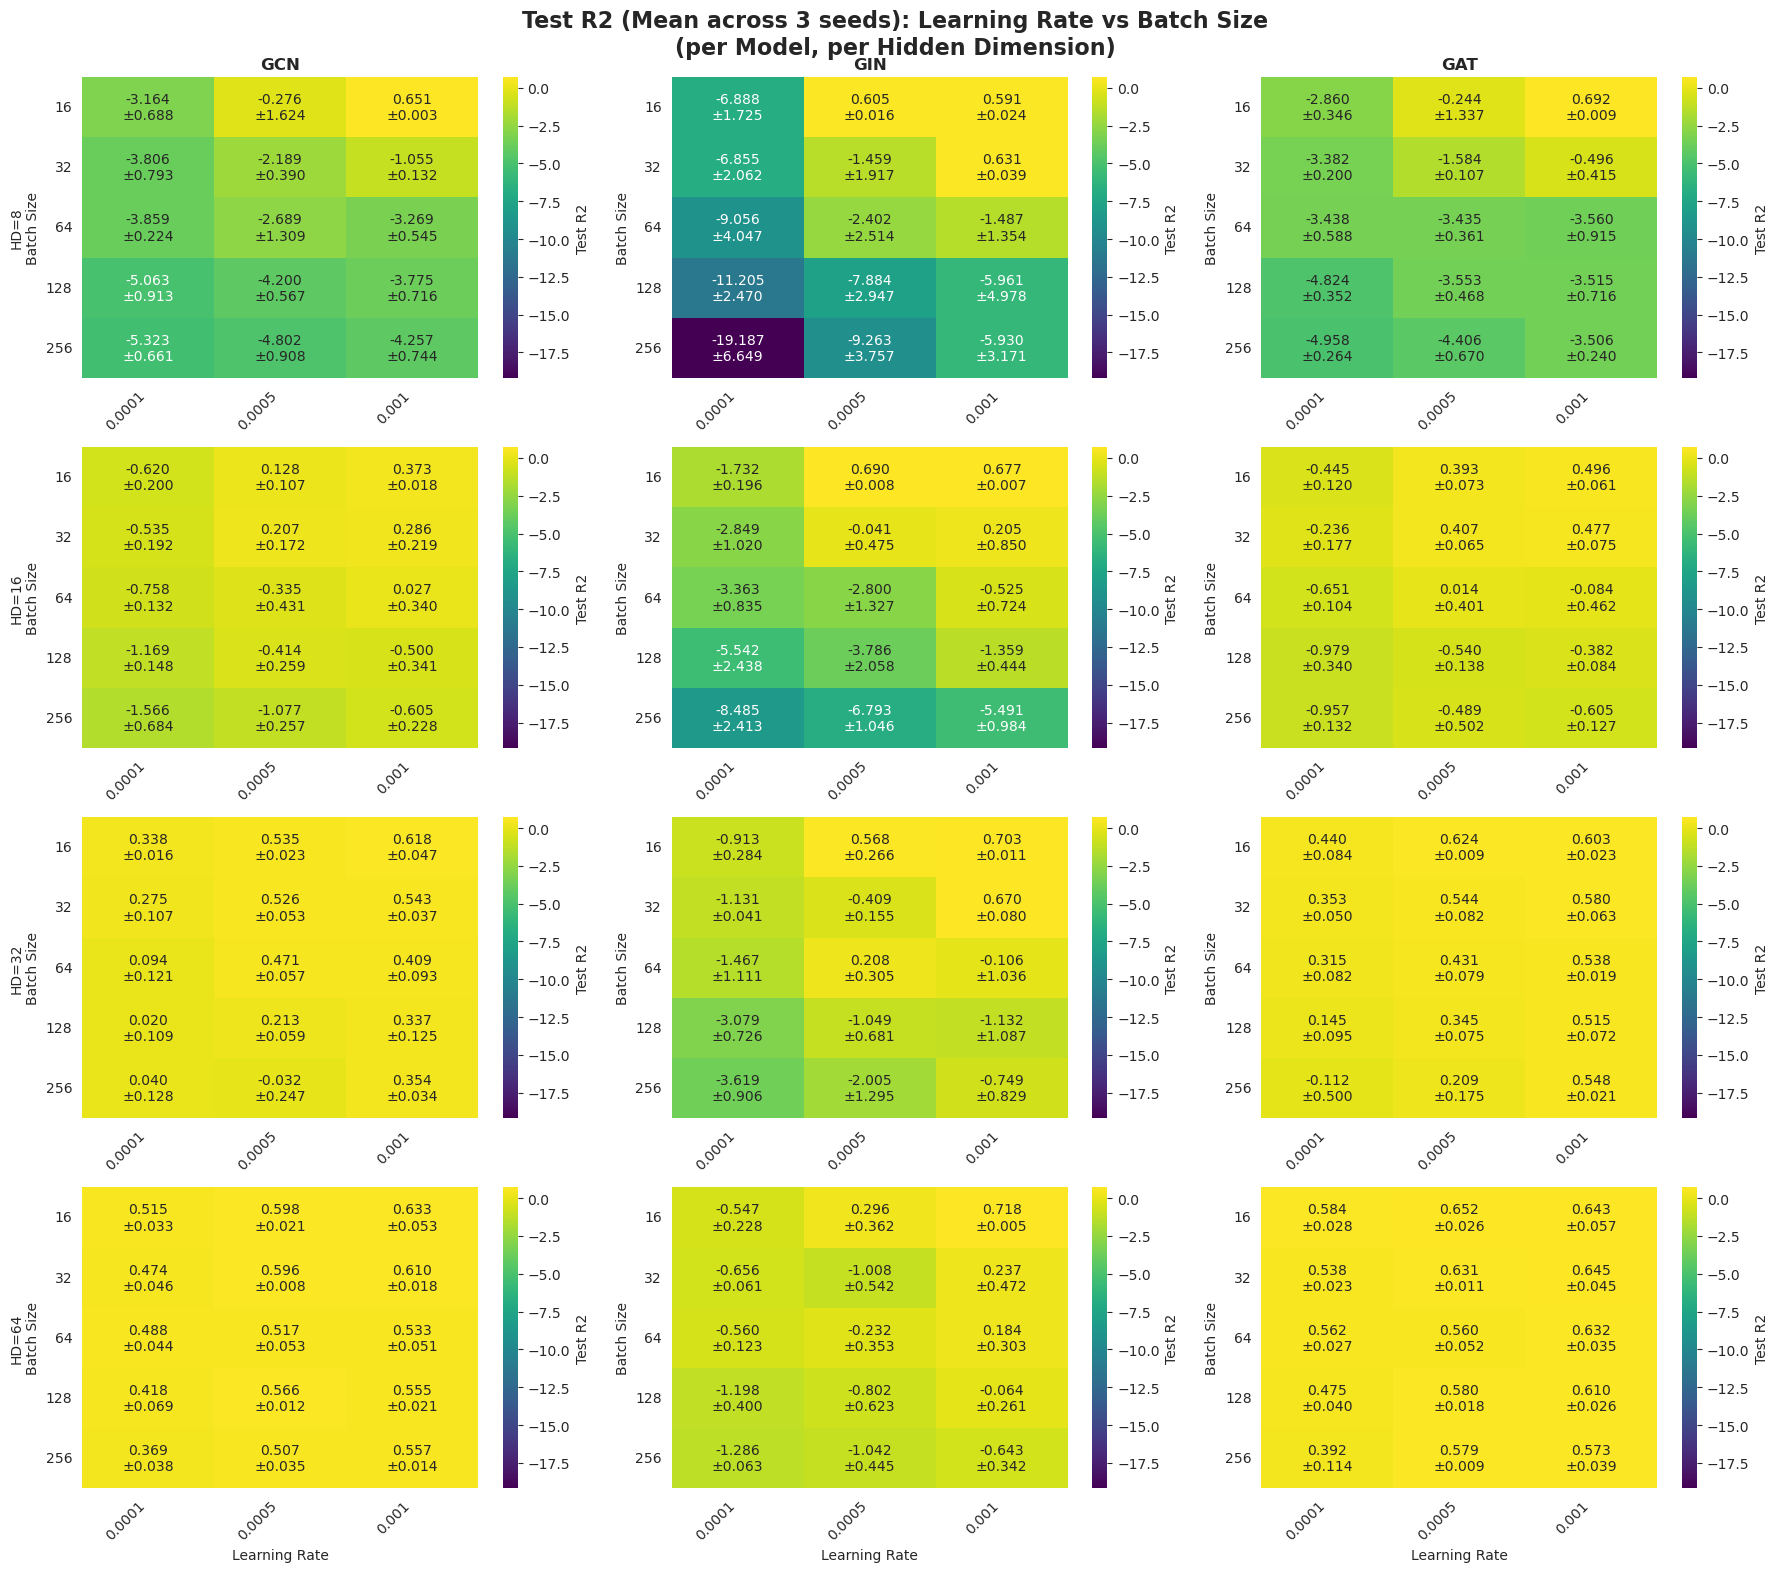

Visualization saved to: test_r2_heatmaps.png

All visualizations use metrics averaged across 3 random seeds for robustness.


In [26]:
# VISUALIZATIONS
BATCH_SIZE_GRID = [16, 32, 64, 128, 256]
HIDDEN_DIM_GRID = [8, 16, 32, 64]
LEARNING_RATE_GRID = [0.001, 0.0005, 0.0001]
results_per_seed_df = pd.read_csv('GNN_hyperparameter_screening_results_per_seed.csv')
results_df = pd.read_csv('GNN_hyperparameter_screening_results.csv')

# Set style
sns.set_style("whitegrid")

def create_heatmap_grid(results_df, results_per_seed_df, metric_name, title, filename, cmap='viridis'):
    """Create and save heatmap grid for metric across all models and hidden dimensions, with std annotations."""
    fig, axes = plt.subplots(len(HIDDEN_DIM_GRID), 3, figsize=(18, 16))
    
    # Get global min/max for consistent color scale (based on mean)
    all_values = []
    for model in ['gcn', 'gin', 'gat']:
        all_values.extend(results_df[f'{model}_{metric_name}'].values)
    vmin_global, vmax_global = min(all_values), max(all_values)
    
    for hd_idx, hidden_dim in enumerate(HIDDEN_DIM_GRID):
        for model_idx, (model, model_name) in enumerate(zip(['gcn', 'gin', 'gat'], ['GCN', 'GIN', 'GAT'])):
            ax = axes[hd_idx, model_idx]
            
            # Get mean values
            subset = results_df[results_df['hidden_dim'] == hidden_dim]
            pivot_table = subset.pivot(index='batch_size', columns='learning_rate', values=f'{model}_{metric_name}')
            
            # Get std values from per-seed results
            subset_per_seed = results_per_seed_df[results_per_seed_df['hidden_dim'] == hidden_dim]
            metric_cols_std = [col for col in subset_per_seed.columns if col not in ['batch_size', 'hidden_dim', 'learning_rate', 'random_seed']]
            std_df = subset_per_seed.groupby(['batch_size', 'learning_rate'])[metric_cols_std].std().reset_index()
            pivot_std = std_df.pivot(index='batch_size', columns='learning_rate', values=f'{model}_{metric_name}')
            
            # Create custom annotations with mean and std
            annot_data = []
            for i, bs in enumerate(pivot_table.index):
                row = []
                for lr in pivot_table.columns:
                    mean_val = pivot_table.loc[bs, lr]
                    std_val = pivot_std.loc[bs, lr] if (bs in pivot_std.index and lr in pivot_std.columns) else 0.0
                    row.append(f'{mean_val:.3f}\n±{std_val:.3f}')
                annot_data.append(row)
            
            sns.heatmap(pivot_table, annot=annot_data, fmt='', cmap=cmap, ax=ax,
                        cbar_kws={'label': metric_name.replace('_', ' ').title()}, 
                        vmin=vmin_global, vmax=vmax_global)
            
            if hd_idx == 0:
                ax.set_title(model_name, fontsize=12, fontweight='bold')
            if model_idx == 0:
                ax.set_ylabel(f'HD={hidden_dim}\nBatch Size', fontsize=10)
            else:
                ax.set_ylabel('Batch Size', fontsize=10)
            if hd_idx == len(HIDDEN_DIM_GRID) - 1:
                ax.set_xlabel('Learning Rate', fontsize=10)
            else:
                ax.set_xlabel('')
            
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Visualization saved to: {filename}")

# Create heatmaps

create_heatmap_grid(results_df, results_per_seed_df, 'test_r2',
                   'Test R2 (Mean across 3 seeds): Learning Rate vs Batch Size\n(per Model, per Hidden Dimension)',
                   'test_r2_heatmaps.png', cmap='viridis')

print("\nAll visualizations use metrics averaged across 3 random seeds for robustness.")

In [27]:
BATCH_SIZE_GRID, HIDDEN_DIM_GRID, LEARNING_RATE_GRID, RANDOM_SEED_GRID

([16, 32, 64, 128, 256], [8, 16, 32, 64], [0.001, 0.0005, 0.0001], [42, 21, 0])

In [28]:
#use optuna Bayes to find best hyperparameters based on test MCC
import optuna

def objective(trial, model_class):
    # Suggest hyperparameters
    batch_size = trial.suggest_categorical('batch_size', BATCH_SIZE_GRID)
    hidden_dim = trial.suggest_categorical('hidden_dim', HIDDEN_DIM_GRID)
    lr = trial.suggest_categorical('learning_rate', LEARNING_RATE_GRID)
    
    results_per_seed = []

    for seed in RANDOM_SEED_GRID:
        
        # Re-create DataLoaders with the current batch_size
        current_train_loader = DataLoader(
        Subset(train_dataset, train_indices), 
        batch_size=batch_size, 
        shuffle=False, 
        collate_fn=graph_collate
        )
        current_val_loader = DataLoader(
        Subset(train_dataset, val_indices), 
        batch_size=batch_size, 
        shuffle=False, 
        collate_fn=graph_collate
        )
        current_test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        collate_fn=graph_collate
        )   

        # Train model
        model_temp, test_r2, test_rmse, test_mae = training_and_evaluation(
            model_class=model_class,
            train_loader=current_train_loader, 
            val_loader=current_val_loader, 
            test_loader=current_test_loader, 
            num_features=num_features,
            hidden_dim=hidden_dim,
            seed=seed,
            lr=lr,
        )
        results_per_seed.append({
            'batch_size': batch_size,
            'hidden_dim': hidden_dim,
            'learning_rate': lr,
            'random_seed': seed,
            'test_r2': test_r2,
            'test_rmse': test_rmse,
            'test_mae': test_mae
        })

    # Return average test r2 across seeds for this hyperparameter combination
    avg_r2 = np.mean([r['test_r2'] for r in results_per_seed])
    print(f"{model_class.__name__} Trial with batch_size={batch_size}, hidden_dim={hidden_dim}, lr={lr} | Avg Test R2 across seeds: {avg_r2:.4f}")
    return avg_r2

study = optuna.create_study(direction='maximize')
for i in [GCN, GIN, GAT]:
    study.optimize(lambda trial: objective(trial, i), n_trials=20)

[I 2026-02-28 10:34:35,769] A new study created in memory with name: no-name-881793de-2345-4c7f-8426-b92badb1a64a



Training model for REGRESSION: GCN
Epoch 05 | Train Loss: 53.0566 | Val Loss: 50.3418
Epoch 10 | Train Loss: 14.8691 | Val Loss: 9.4012
Epoch 15 | Train Loss: 3.2875 | Val Loss: 0.3084
Epoch 20 | Train Loss: 3.1272 | Val Loss: 0.2776
Epoch 25 | Train Loss: 2.9138 | Val Loss: 0.2493
Epoch 30 | Train Loss: 2.7559 | Val Loss: 0.2296
Epoch 35 | Train Loss: 2.5735 | Val Loss: 0.2083
Epoch 40 | Train Loss: 2.4319 | Val Loss: 0.1949
Epoch 45 | Train Loss: 2.3730 | Val Loss: 0.1764
Early stopping at epoch 50 | Best Val Loss: 0.1764
Test MSE Loss: 0.1655
Test RMSE: 0.4068
Test MAE: 0.2965
Test R2: -0.1065

Training model for REGRESSION: GCN
Epoch 05 | Train Loss: 53.2935 | Val Loss: 50.4281
Epoch 10 | Train Loss: 10.0232 | Val Loss: 5.0587
Epoch 15 | Train Loss: 2.9480 | Val Loss: 0.2705
Epoch 20 | Train Loss: 2.7908 | Val Loss: 0.2520
Epoch 25 | Train Loss: 2.6994 | Val Loss: 0.2434
Epoch 30 | Train Loss: 2.6249 | Val Loss: 0.2301
Epoch 35 | Train Loss: 2.5722 | Val Loss: 0.2273
Epoch 40 | Tr

[I 2026-02-28 10:39:58,943] Trial 0 finished with value: 0.04034430213005791 and parameters: {'batch_size': 256, 'hidden_dim': 32, 'learning_rate': 0.0001}. Best is trial 0 with value: 0.04034430213005791.


Test MSE Loss: 0.1305
Test RMSE: 0.3613
Test MAE: 0.2665
Test R2: 0.1275
GCN Trial with batch_size=256, hidden_dim=32, lr=0.0001 | Avg Test R2 across seeds: 0.0403

Training model for REGRESSION: GCN
Epoch 05 | Train Loss: 1.7448 | Val Loss: 0.1119
Epoch 10 | Train Loss: 1.1549 | Val Loss: 0.0714
Epoch 15 | Train Loss: 0.6737 | Val Loss: 0.0679
Epoch 20 | Train Loss: 0.3446 | Val Loss: 0.0664
Epoch 25 | Train Loss: 0.1653 | Val Loss: 0.0680
Epoch 30 | Train Loss: 0.0895 | Val Loss: 0.0626
Epoch 35 | Train Loss: 0.0674 | Val Loss: 0.0588
Epoch 40 | Train Loss: 0.0620 | Val Loss: 0.0596
Epoch 45 | Train Loss: 0.0600 | Val Loss: 0.0564
Epoch 50 | Train Loss: 0.0611 | Val Loss: 0.0569
Epoch 55 | Train Loss: 0.0586 | Val Loss: 0.0586
Early stopping at epoch 57 | Best Val Loss: 0.0557
Test MSE Loss: 0.0503
Test RMSE: 0.2243
Test MAE: 0.1734
Test R2: 0.6638

Training model for REGRESSION: GCN
Epoch 05 | Train Loss: 1.7156 | Val Loss: 0.0750
Epoch 10 | Train Loss: 1.1417 | Val Loss: 0.1652
Epo

[I 2026-02-28 10:46:28,334] Trial 1 finished with value: 0.6155843689407948 and parameters: {'batch_size': 16, 'hidden_dim': 32, 'learning_rate': 0.001}. Best is trial 1 with value: 0.6155843689407948.


...

Test MSE Loss: 0.0466
Test RMSE: 0.2159
Test MAE: 0.1636
Test R2: 0.6884
GAT Trial with batch_size=16, hidden_dim=8, lr=0.001 | Avg Test R2 across seeds: 0.6893

Training model for REGRESSION: GAT
Epoch 05 | Train Loss: 4.6554 | Val Loss: 0.2962
Epoch 10 | Train Loss: 1.9780 | Val Loss: 0.2421
Epoch 15 | Train Loss: 0.5844 | Val Loss: 0.0799
Epoch 20 | Train Loss: 0.1093 | Val Loss: 0.0619
Epoch 25 | Train Loss: 0.0688 | Val Loss: 0.0606
Epoch 30 | Train Loss: 0.0672 | Val Loss: 0.0534
Epoch 35 | Train Loss: 0.0650 | Val Loss: 0.0520
Early stopping at epoch 39 | Best Val Loss: 0.0513
Test MSE Loss: 0.0480
Test RMSE: 0.2190
Test MAE: 0.1665
Test R2: 0.6794

Training model for REGRESSION: GAT
Epoch 05 | Train Loss: 4.7383 | Val Loss: 0.3007
Epoch 10 | Train Loss: 2.1770 | Val Loss: 0.4284
Epoch 15 | Train Loss: 0.6637 | Val Loss: 0.1078
Epoch 20 | Train Loss: 0.1264 | Val Loss: 0.0669
Epoch 25 | Train Loss: 0.0709 | Val Loss: 0.0604
Epoch 30 | Train Loss: 0.0676 | Val Loss: 0.0564
Epoch 

[I 2026-02-28 16:13:08,285] Trial 58 finished with value: 0.6919041776319609 and parameters: {'batch_size': 16, 'hidden_dim': 8, 'learning_rate': 0.001}. Best is trial 55 with value: 0.6936558976624964.


Test MSE Loss: 0.0463
Test RMSE: 0.2152
Test MAE: 0.1628
Test R2: 0.6905
GAT Trial with batch_size=16, hidden_dim=8, lr=0.001 | Avg Test R2 across seeds: 0.6919

Training model for REGRESSION: GAT
Epoch 05 | Train Loss: 6.8285 | Val Loss: 0.8833
Epoch 10 | Train Loss: 6.2026 | Val Loss: 0.7807
Epoch 15 | Train Loss: 5.8794 | Val Loss: 0.6086
Epoch 20 | Train Loss: 5.3839 | Val Loss: 0.5423
Early stopping at epoch 25 | Best Val Loss: 0.5423
Test MSE Loss: 0.5308
Test RMSE: 0.7285
Test MAE: 0.6641
Test R2: -2.5483

Training model for REGRESSION: GAT
Epoch 05 | Train Loss: 6.8412 | Val Loss: 0.9118
Epoch 10 | Train Loss: 6.5839 | Val Loss: 0.8049
Epoch 15 | Train Loss: 6.2299 | Val Loss: 0.6733
Early stopping at epoch 19 | Best Val Loss: 0.5797
Test MSE Loss: 0.5682
Test RMSE: 0.7538
Test MAE: 0.6878
Test R2: -2.7988

Training model for REGRESSION: GAT
Epoch 05 | Train Loss: 6.9368 | Val Loss: 0.8540
Epoch 10 | Train Loss: 6.3830 | Val Loss: 0.6959
Early stopping at epoch 11 | Best Val Lo

[I 2026-02-28 16:17:55,540] Trial 59 finished with value: -2.859865003090102 and parameters: {'batch_size': 16, 'hidden_dim': 8, 'learning_rate': 0.0001}. Best is trial 55 with value: 0.6936558976624964.


Test MSE Loss: 0.6331
Test RMSE: 0.7957
Test MAE: 0.7248
Test R2: -3.2325
GAT Trial with batch_size=16, hidden_dim=8, lr=0.0001 | Avg Test R2 across seeds: -2.8599


In [ ]:
#[I 2026-02-28 10:46:28,334] Trial 1 finished with value: 0.6155843689407948 and parameters: {'batch_size': 16, 'hidden_dim': 32, 'learning_rate': 0.001}. Best is trial 1 with value: 0.6155843689407948.
#GCN Trial with batch_size=16, hidden_dim=32, lr=0.001 | Avg Test R2 across seeds: 0.6156
#[I 2026-02-28 11:44:38,597] Trial 20 finished with value: 0.6871376463536212 and parameters: {'batch_size': 16, 'hidden_dim': 16, 'learning_rate': 0.001}. Best is trial 20 with value: 0.6871376463536212.
#GIN Trial with batch_size=16, hidden_dim=16, lr=0.001 | Avg Test R2 across seeds: 0.6871
#[I 2026-02-28 15:46:27,275] Trial 55 finished with value: 0.6936558976624964 and parameters: {'batch_size': 16, 'hidden_dim': 8, 'learning_rate': 0.001}. Best is trial 55 with value: 0.6936558976624964.
#GAT Trial with batch_size=16, hidden_dim=8, lr=0.001 | Avg Test R2 across seeds: 0.6937

#For GCN and GIN, Bayesian optimization failed to find better hyperparameters than the grid search (20 trials maybe not enough). For GAT, it found a slightly better combination (16, 8, 0.001) than the grid search best (16, 16, 0.001), but the improvement is small (0.6937 vs 0.6921).

In [36]:
#retrain best GCN model with best hyperparameters and save model to pt file
best_batch_size = 16
best_hidden_dim = 8
best_lr = 0.001
best_seed = 42
# Re-create DataLoaders with the best batch size
best_train_loader = DataLoader(
    Subset(train_dataset, train_indices), 
    batch_size=best_batch_size, 
    shuffle=False, 
    collate_fn=graph_collate
)
best_val_loader = DataLoader(
    Subset(train_dataset, val_indices), 
    batch_size=best_batch_size, 
    shuffle=False,
    collate_fn=graph_collate
)
best_test_loader = DataLoader(
    test_dataset, 
    batch_size=best_batch_size, 
    shuffle=False,
    collate_fn=graph_collate
)
# Train the best GCN model
best_gcn_model, test_r2, test_rmse, test_mae = training_and_evaluation(
    model_class=GCN,
    train_loader=best_train_loader, 
    val_loader=best_val_loader, 
    test_loader=best_test_loader, 
    num_features=num_features,
    hidden_dim=best_hidden_dim,
    seed=best_seed,
    lr=best_lr,
)
# Save the best model
torch.save(best_gcn_model.state_dict(), 'best_gcn_model.pt')           


Training model for REGRESSION: GCN
Epoch 05 | Train Loss: 4.7588 | Val Loss: 0.4896
Epoch 10 | Train Loss: 2.0643 | Val Loss: 0.2280
Epoch 15 | Train Loss: 0.6313 | Val Loss: 0.0998
Epoch 20 | Train Loss: 0.1285 | Val Loss: 0.0743
Epoch 25 | Train Loss: 0.0787 | Val Loss: 0.0683
Epoch 30 | Train Loss: 0.0750 | Val Loss: 0.0623
Epoch 35 | Train Loss: 0.0722 | Val Loss: 0.0602
Epoch 40 | Train Loss: 0.0712 | Val Loss: 0.0602
Epoch 45 | Train Loss: 0.0700 | Val Loss: 0.0579
Epoch 50 | Train Loss: 0.0706 | Val Loss: 0.0599
Epoch 55 | Train Loss: 0.0695 | Val Loss: 0.0597
Epoch 60 | Train Loss: 0.0697 | Val Loss: 0.0595
Epoch 65 | Train Loss: 0.0697 | Val Loss: 0.0590
Epoch 70 | Train Loss: 0.0680 | Val Loss: 0.0568
Early stopping at epoch 72 | Best Val Loss: 0.0565
Test MSE Loss: 0.0497
Test RMSE: 0.2229
Test MAE: 0.1716
Test R2: 0.6677


In [ ]:
#retrain best GIN model with best hyperparameters and save model to pt file
best_batch_size = 16
best_hidden_dim = 64
best_lr = 0.001
best_seed = 42
# Re-create DataLoaders with the best batch size
best_train_loader = DataLoader(
    Subset(train_dataset, train_indices), 
    batch_size=best_batch_size, 
    shuffle=False, 
    collate_fn=graph_collate
)
best_val_loader = DataLoader(
    Subset(train_dataset, val_indices), 
    batch_size=best_batch_size, 
    shuffle=False,
    collate_fn=graph_collate
)
best_test_loader = DataLoader(
    test_dataset, 
    batch_size=best_batch_size, 
    shuffle=False,
    collate_fn=graph_collate
)
# Train the best GIN model
best_gin_model, test_r2, test_rmse, test_mae = training_and_evaluation(
    model_class=GIN,
    train_loader=best_train_loader, 
    val_loader=best_val_loader, 
    test_loader=best_test_loader, 
    num_features=num_features,
    hidden_dim=best_hidden_dim,
    seed=best_seed,
    lr=best_lr,
)
# Save the best model
torch.save(best_gin_model.state_dict(), 'best_gin_model.pt')  


Training model for REGRESSION: GIN
Epoch 05 | Train Loss: 1.3765 | Val Loss: 0.3546
Epoch 10 | Train Loss: 0.9429 | Val Loss: 0.2880
Epoch 15 | Train Loss: 0.6362 | Val Loss: 0.1703
Epoch 20 | Train Loss: 0.4078 | Val Loss: 0.0969
Epoch 25 | Train Loss: 0.2559 | Val Loss: 0.0968
Epoch 30 | Train Loss: 0.1601 | Val Loss: 0.0601
Epoch 35 | Train Loss: 0.0950 | Val Loss: 0.0476
Epoch 40 | Train Loss: 0.0674 | Val Loss: 0.0438
Epoch 45 | Train Loss: 0.0537 | Val Loss: 0.0432
Early stopping at epoch 50 | Best Val Loss: 0.0432
Test MSE Loss: 0.0409
Test RMSE: 0.2022
Test MAE: 0.1447
Test R2: 0.7266
Best GIN model saved to: best_gin_model.pt


In [ ]:
#retrain best GAT model with best hyperparameters and save model to pt file
best_batch_size = 16
best_hidden_dim = 8
best_lr = 0.001
best_seed = 42
# Re-create DataLoaders with the best batch size
best_train_loader = DataLoader(
    Subset(train_dataset, train_indices), 
    batch_size=best_batch_size, 
    shuffle=False, 
    collate_fn=graph_collate
)
best_val_loader = DataLoader(
    Subset(train_dataset, val_indices), 
    batch_size=best_batch_size, 
    shuffle=False,
    collate_fn=graph_collate
)
best_test_loader = DataLoader(
    test_dataset, 
    batch_size=best_batch_size, 
    shuffle=False,
    collate_fn=graph_collate
)
# Train the best GAT model
best_gat_model, test_r2, test_rmse, test_mae = training_and_evaluation(
    model_class=GAT,
    train_loader=best_train_loader, 
    val_loader=best_val_loader, 
    test_loader=best_test_loader, 
    num_features=num_features,
    hidden_dim=best_hidden_dim,
    seed=best_seed,
    lr=best_lr,
)
# Save the best model
torch.save(best_gat_model.state_dict(), 'best_gat_model.pt')   


Training model for REGRESSION: GAT
Epoch 05 | Train Loss: 4.6554 | Val Loss: 0.2962
Epoch 10 | Train Loss: 1.9782 | Val Loss: 0.2420
Epoch 15 | Train Loss: 0.5845 | Val Loss: 0.0798
Epoch 20 | Train Loss: 0.1093 | Val Loss: 0.0619
Epoch 25 | Train Loss: 0.0686 | Val Loss: 0.0597
Epoch 30 | Train Loss: 0.0673 | Val Loss: 0.0536
Epoch 35 | Train Loss: 0.0650 | Val Loss: 0.0519
Early stopping at epoch 39 | Best Val Loss: 0.0510
Test MSE Loss: 0.0476
Test RMSE: 0.2182
Test MAE: 0.1656
Test R2: 0.6818
Best GAT model saved to: best_gat_model.pt
